# Análisis Exploratorio de Datos (EDA) - Riesgo Crediticio

### Objetivo: Comprender la estructura de los datos, identificar valores nulos, corregir tipos de datos y analizar el comportamiento de las variables independientes respecto a la variable objetivo (Pago_atiempo).

## 1. Exploración Inicial de Datos

En esta sección realizaremos la carga de datos, revisión de nulos y estandarización de los tipos de variables.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Para mantener el notebook limpio de alertas
pd.options.display.float_format = '{:.2f}'.format # Para mostrar los números con 2 decimales

# Configuración visual
sns.set_theme(style="whitegrid")

# 1. Carga de los datos (Usamos pd.read_excel ya que es un archivo .xlsx)
df = pd.read_excel('../Base_de_datos.xlsx')

print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.\n")
display(df.head())

El dataset tiene 10763 filas y 23 columnas.



,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.00,10,42,Independiente,8000000,2500000,341296,88.77,...,0.00,51258.00,51258.00,0.00,5,0,0,908526.00,Estable,1
1,4,2025-04-22 09:47:35,840000.00,6,60,Empleado,3000000,2000000,124876,95.23,...,0.00,8673.00,8673.00,0.00,0,0,2,939017.00,Creciente,1
2,9,2026-01-08 12:22:40,5974028.40,10,36,Independiente,4036000,829000,529554,47.61,...,0.00,18702.00,18702.00,0.00,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.00,6,48,Empleado,1524547,498000,252420,95.23,...,0.00,15782.00,15782.00,0.00,3,0,0,1536193.00,Creciente,1
4,9,2025-04-26 11:24:26,2781636.00,11,44,Empleado,5000000,4000000,217037,95.23,...,0.00,204804.00,204804.00,0.00,3,0,1,933473.00,Creciente,1


### 1.1 Unificación de Nulos y Revisión

Vamos a asegurar que cualquier representación de vacío (espacios, strings 'NA', '?', 'N/A') se convierta a un nulo real de Numpy (np.nan) para poder contabilizarlos correctamente.

In [3]:
# Reemplazar valores que comúnmente son nulos ocultos
df.replace(['', ' ', 'NA', 'N/A', '?', 'null', 'Null'], np.nan, inplace=True)

# Calcular el porcentaje de nulos por columna
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100
df_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje_nulos})

# Mostrar solo las columnas que tienen nulos
df_nulos_filtrado = df_nulos[df_nulos['Nulos'] > 0].sort_values(by='Porcentaje (%)', ascending=False)

if df_nulos_filtrado.empty:
    print("No se encontraron valores nulos en el dataset.")
else:
    print("Columnas con valores nulos:")
    display(df_nulos_filtrado)

Columnas con valores nulos:


,Nulos,Porcentaje (%)
tendencia_ingresos,2932,27.24
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06


### 1.2 Corrección de Tipos de Datos (Casteo)

Identificamos las variables categóricas, numéricas y fechas, ajustándolas a su tipo de dato correcto para optimizar la memoria y evitar errores en gráficas futuras.

In [4]:
# Verificamos los tipos de datos actuales
print("Tipos de datos ORIGINALES:")
print(df.dtypes)

# 1. Convertir la variable de fecha a formato datetime
if 'fecha_prestamo' in df.columns:
    df['fecha_prestamo'] = pd.to_datetime(df['fecha_prestamo'], errors='coerce')

# 2. Convertir variables que deberían ser categóricas a tipo 'category'
# Esto incluye nuestra variable objetivo (Pago_atiempo) que es dicotómica (0, 1)
variables_categoricas = ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos', 'Pago_atiempo']

for col in variables_categoricas:
    if col in df.columns:
        df[col] = df[col].astype('category')

print("\n-------------------------------------------")
print("Tipos de datos CORREGIDOS:")
print(df.dtypes)

Tipos de datos ORIGINALES:
tipo_credito                              int64
fecha_prestamo                   datetime64[ns]
capital_prestado                        float64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                             object
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorFinanciero                 int64
creditos_sectorCooperativo                int64
creditos_sectorReal                       int64
promedio_ingr

### 1.3 Eliminación de Variables Irrelevantes

En este paso debemos descartar columnas que no aportan valor predictivo (como IDs de cliente, nombres, etc.) o que tienen demasiados nulos.

In [5]:
# vamos a simplificar el modelo
# eliminando variables que requieren mucho preprocesamiento o tienen muchos nulos.
# - 'fecha_prestamo': Las fechas requieren feature engineering complejo para modelos de ML.
# - 'huella_consulta': Eliminada por falta de contexto de negocio.
# - 'tendencia_ingresos' y 'promedio_ingresos_datacredito': Tienen ~27% de nulos.

columnas_a_eliminar = [
    'fecha_prestamo', 
    'huella_consulta', 
    'tendencia_ingresos', 
    'promedio_ingresos_datacredito'
]

if columnas_a_eliminar:
    df.drop(columns=columnas_a_eliminar, inplace=True, errors='ignore')
    print(f"Se han eliminado las columnas: {columnas_a_eliminar}")
else:
    print("No se han eliminado variables en esta etapa. El dataset se mantiene intacto.")


Se han eliminado las columnas: ['fecha_prestamo', 'huella_consulta', 'tendencia_ingresos', 'promedio_ingresos_datacredito']


## 2. Exploración de Datos y Descripción (Análisis Univariable)

En esta fase realizaremos una descripción estadística detallada de las variables numéricas y categóricas, evaluando su tendencia central, dispersión y forma (asimetría y curtosis).

In [6]:
# Separamos las variables por su tipo para facilitar el análisis
vars_numericas = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
vars_categoricas = df.select_dtypes(include=['category', 'object']).columns.tolist()

print(f"Variables numéricas ({len(vars_numericas)}): {vars_numericas}")
print(f"Variables categóricas ({len(vars_categoricas)}): {vars_categoricas}")

# 1. Descripción estadística de variables numéricas
desc_num = df[vars_numericas].describe().T
desc_num['varianza'] = df[vars_numericas].var()
desc_num['skewness (asimetría)'] = df[vars_numericas].skew()
desc_num['kurtosis (curtosis)'] = df[vars_numericas].kurtosis()

print("\n--- Estadísticas Descriptivas (Numéricas) ---")
display(desc_num)

# 2. Descripción de variables categóricas
print("\n--- Estadísticas Descriptivas (Categóricas) ---")
display(df[vars_categoricas].describe().T)

Variables numéricas (16): ['capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal']
Variables categóricas (3): ['tipo_credito', 'tipo_laboral', 'Pago_atiempo']

--- Estadísticas Descriptivas (Numéricas) ---


,count,mean,std,min,25%,50%,75%,max,varianza,skewness (asimetría),kurtosis (curtosis)
capital_prestado,10763.00,2434315.00,1909642.76,360000.00,1224831.00,1921920.00,3084840.00,41444152.80,3646735466988.66,3.72,35.32
plazo_meses,10763.00,10.58,6.63,2.00,6.00,10.00,12.00,90.00,43.98,2.46,7.78
edad_cliente,10763.00,43.95,15.06,19.00,33.00,42.00,53.00,123.00,226.83,1.93,7.87
salario_cliente,10763.00,17216431.46,355476717.60,0.00,2000000.00,3000000.00,4875808.00,22000000000.00,126363696758146032.00,43.78,2211.23
total_otros_prestamos,10763.00,6238869.65,118418316.94,0.00,500000.00,1000000.00,2000000.00,6787675263.00,14022897787155474.00,38.46,1719.28
cuota_pactada,10763.00,243617.41,210493.69,23944.00,121041.50,182863.00,287833.50,3816752.00,44307595469.58,3.79,26.65
puntaje,10763.00,91.17,16.47,-38.01,95.23,95.23,95.23,95.23,271.11,-4.87,24.08
puntaje_datacredito,10757.00,780.79,104.88,-7.00,757.00,791.00,825.00,999.00,10999.40,-5.64,39.44
cant_creditosvigentes,10763.00,5.73,3.98,0.00,3.00,5.00,8.00,62.00,15.82,1.80,8.62
saldo_mora,10607.00,7.75,225.96,0.00,0.00,0.00,0.00,12534.00,51055.72,40.57,1845.71



--- Estadísticas Descriptivas (Categóricas) ---


,count,unique,top,freq
tipo_credito,10763,6,4,7747
tipo_laboral,10763,2,Empleado,6754
Pago_atiempo,10763,2,1,10252


### 2.1 Visualización Univariable (Distribuciones)

Para las variables numéricas utilizaremos histogramas y diagramas de caja (boxplots) para identificar valores atípicos (outliers). Para las categóricas, usaremos gráficos de conteo.

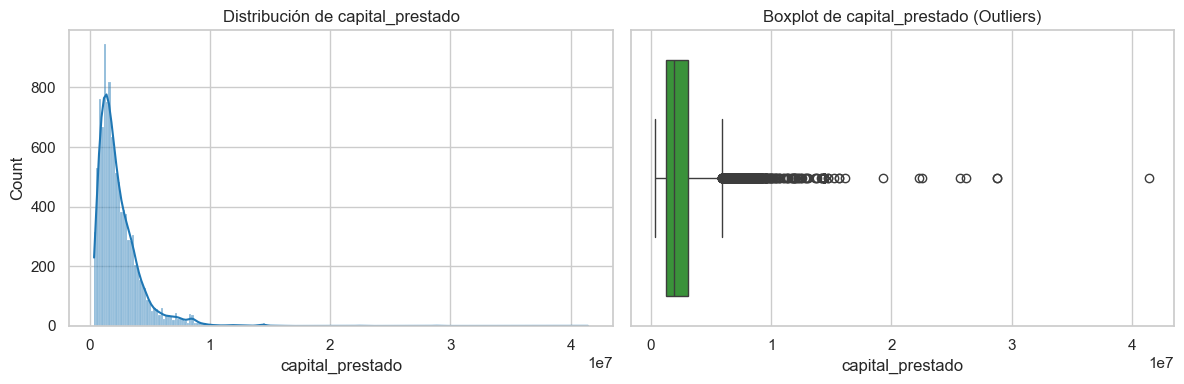

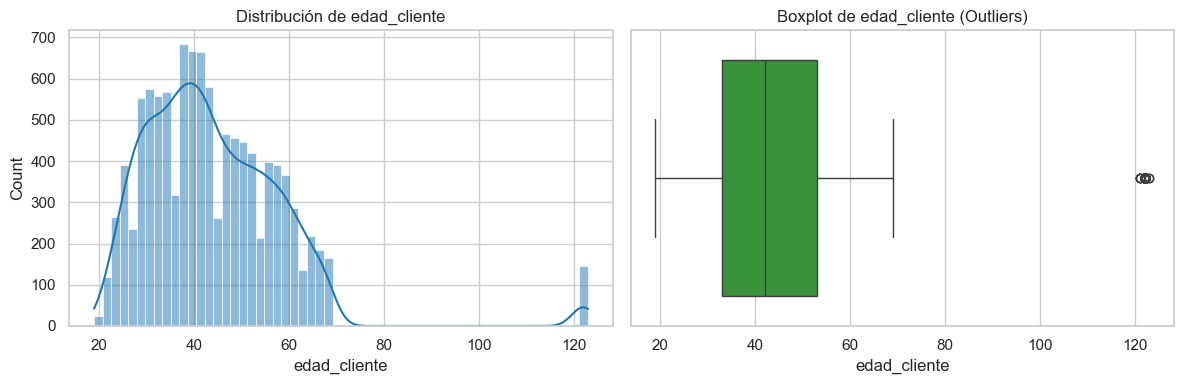

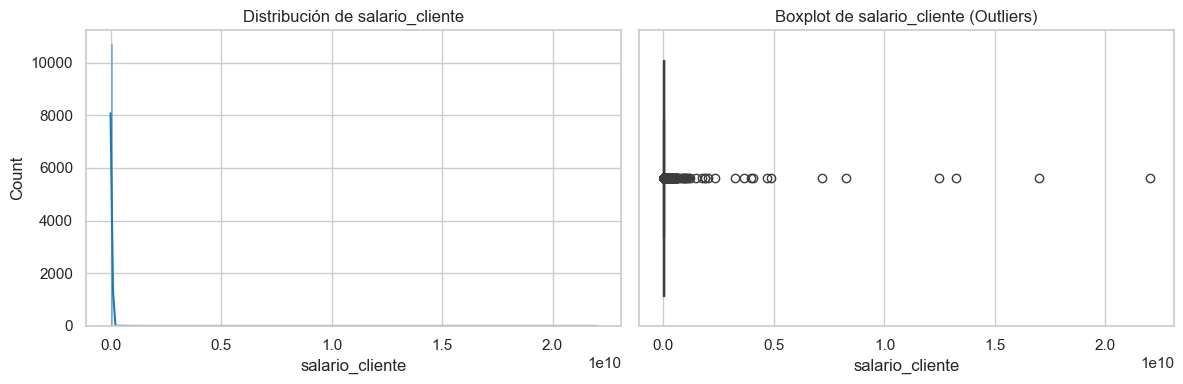

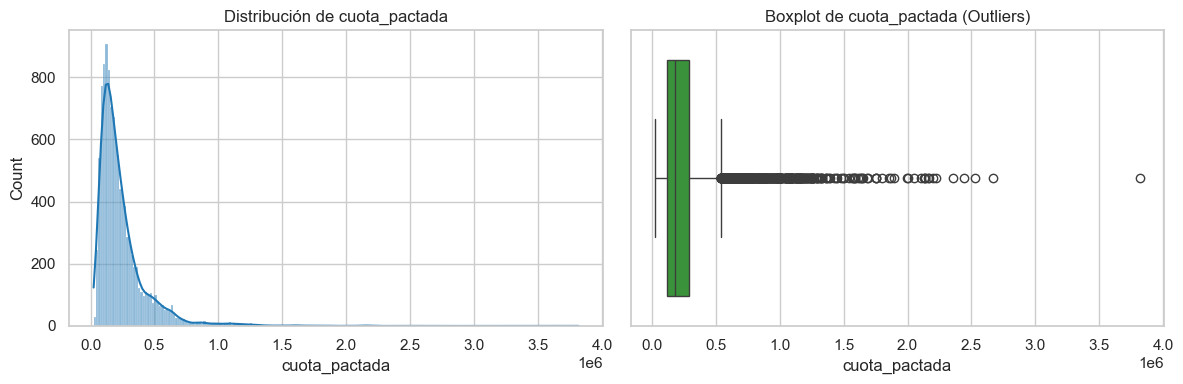

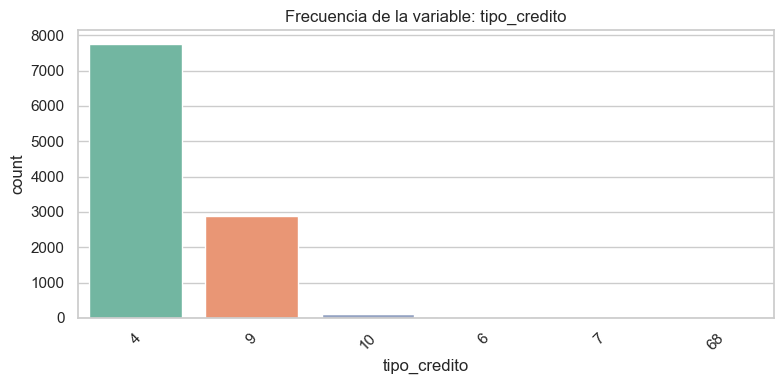

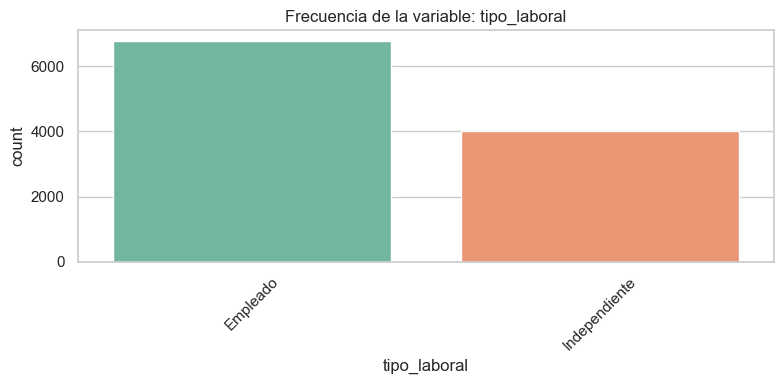

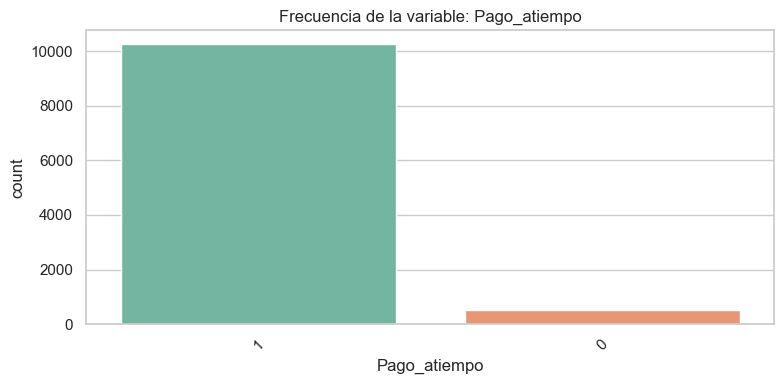

In [7]:
# Gráficos para variables NUMÉRICAS (Histograma + Boxplot)
# Seleccionamos algunas variables numéricas clave para no saturar el notebook (puedes agregar más)
num_clave = ['capital_prestado', 'edad_cliente', 'salario_cliente', 'cuota_pactada']

for col in num_clave:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histograma
    sns.histplot(df[col], kde=True, ax=ax[0], color='#1f77b4')
    ax[0].set_title(f'Distribución de {col}')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=ax[1], color='#2ca02c')
    ax[1].set_title(f'Boxplot de {col} (Outliers)')
    
    plt.tight_layout()
    plt.show()

# Gráficos para variables CATEGÓRICAS
for col in vars_categoricas:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)
    plt.title(f'Frecuencia de la variable: {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 3. Análisis Bivariable (Relación con la Variable Objetivo)

El objetivo de este proyecto es predecir si un cliente pagará a tiempo o no (Pago_atiempo). Vamos a cruzar las variables independientes contra este Target para encontrar patrones iniciales.

--- Análisis de Variables Numéricas vs Target ---


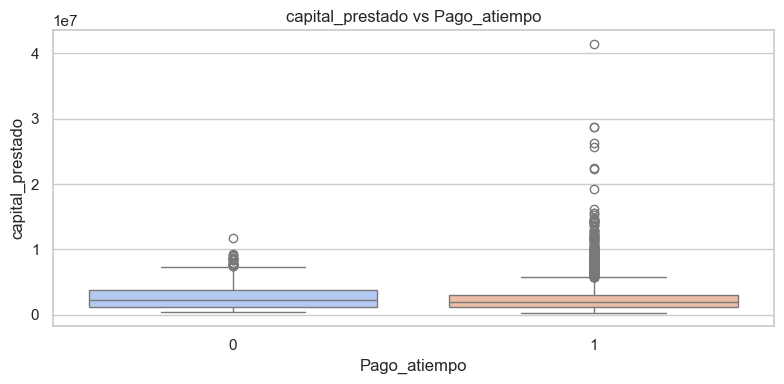

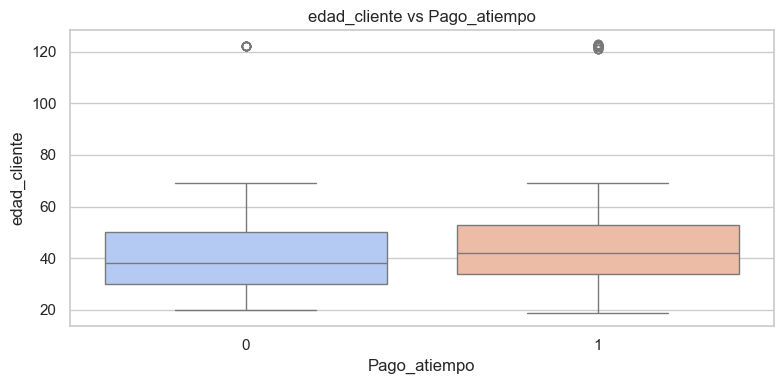

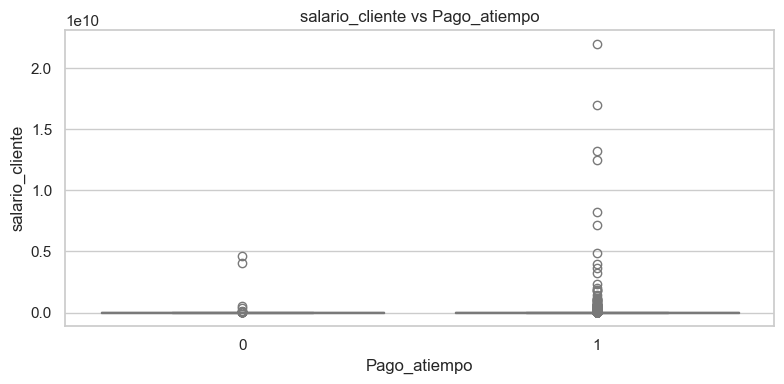

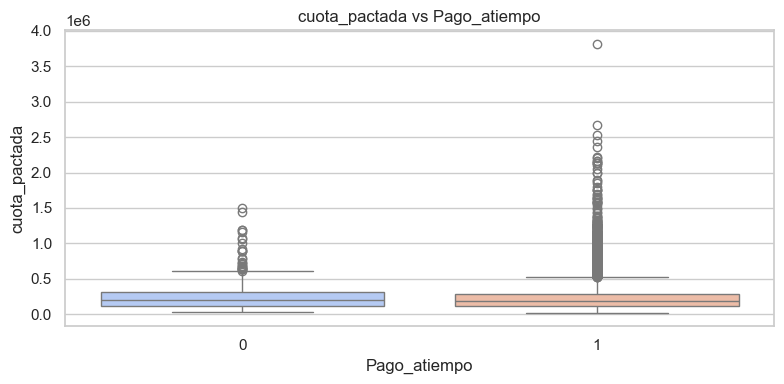

--- Análisis de Variables Categóricas vs Target ---


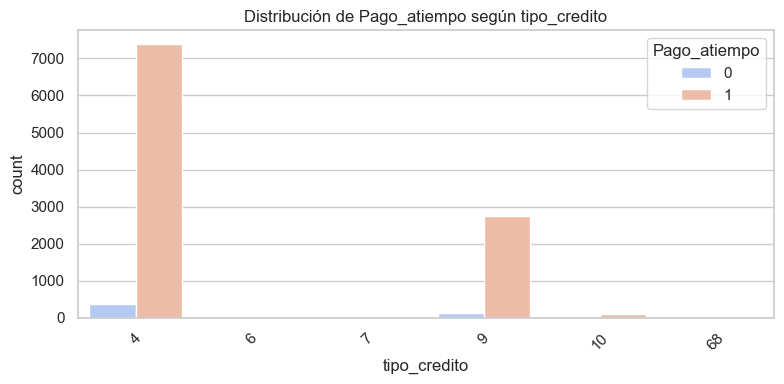

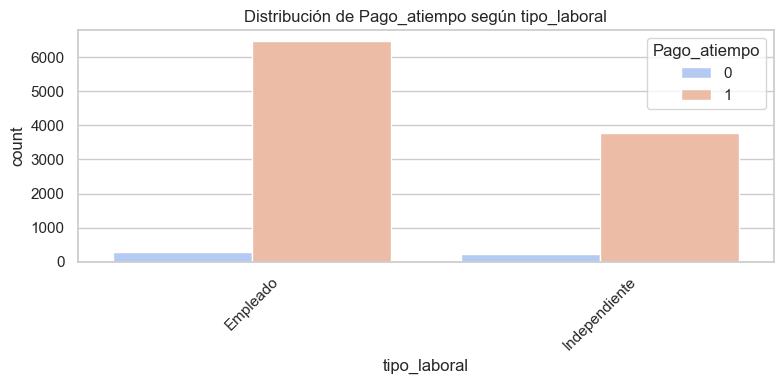

In [8]:
target = 'Pago_atiempo'

print("--- Análisis de Variables Numéricas vs Target ---")
# Usamos Boxplots para ver si la media de una variable cambia dependiendo de si pagó o no
for col in num_clave:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=target, y=col, palette='coolwarm')
    plt.title(f'{col} vs {target}')
    plt.tight_layout()
    plt.show()

print("--- Análisis de Variables Categóricas vs Target ---")
# Usamos Countplots apilados para ver la proporción de pagos a tiempo por cada categoría
cat_clave = [col for col in vars_categoricas if col != target]

for col in cat_clave:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue=target, palette='coolwarm')
    plt.title(f'Distribución de {target} según {col}')
    plt.xticks(rotation=45)
    plt.legend(title=target, loc='upper right')
    plt.tight_layout()
    plt.show()

## 4. Análisis Multivariable

En esta sección exploraremos la relación entre múltiples variables independientes para descartar multicolinealidad (variables que dicen lo mismo) y encontrar patrones más complejos.

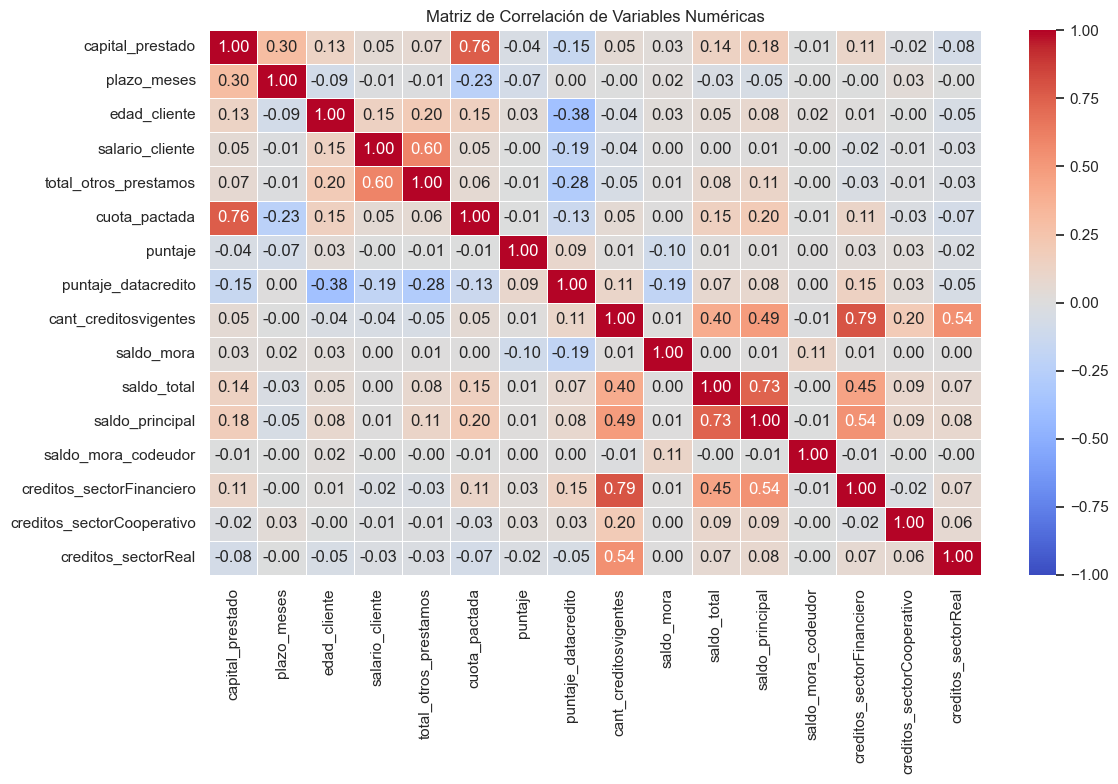

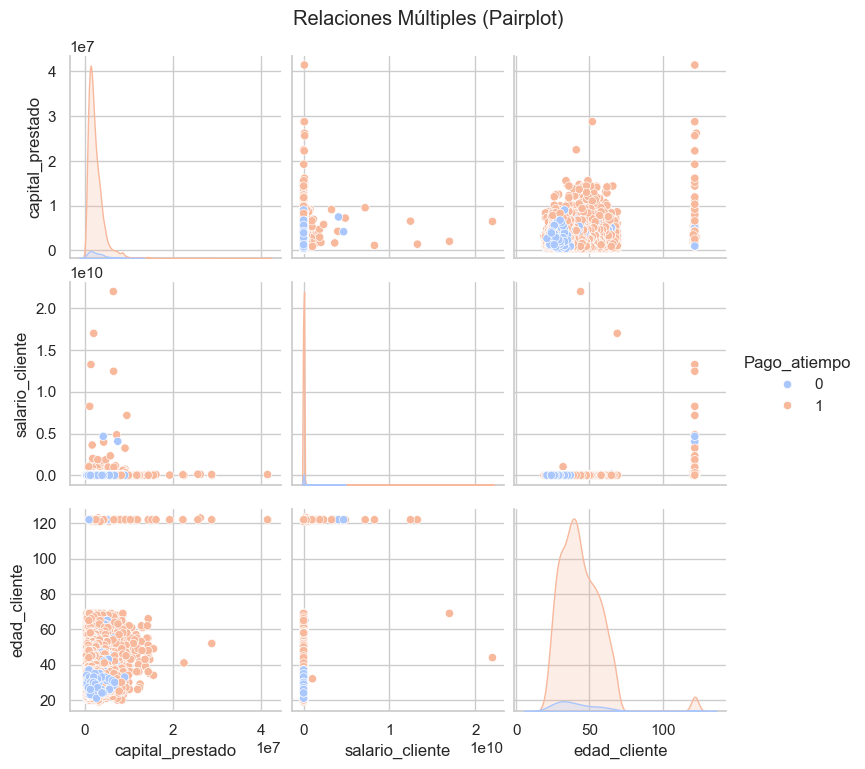

In [9]:
# 1. Matriz de Correlación (Solo variables numéricas)
plt.figure(figsize=(12, 8))
# Calculamos la correlación de Pearson
correlacion = df[vars_numericas].corr()

# Creamos un mapa de calor (Heatmap)
sns.heatmap(correlacion, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.tight_layout()
plt.show()

# 2. Pairplot (Gráfico de dispersión múltiple)
# Usamos solo unas pocas variables clave para que el gráfico sea legible y no consuma mucha memoria
cols_pairplot = ['capital_prestado', 'salario_cliente', 'edad_cliente', target]
sns.pairplot(df[cols_pairplot], hue=target, palette='coolwarm', diag_kind='kde')
plt.suptitle('Relaciones Múltiples (Pairplot)', y=1.02)
plt.show()

### 4.1 Tablas Cruzadas (Crosstabs) para variables categóricas

Veamos cómo interactúan el tipo de crédito y el tipo laboral con nuestra variable objetivo de forma porcentual.

In [ ]:
print("--- Probabilidad de Pago a Tiempo según Tipo Laboral ---")
crosstab_laboral = pd.crosstab(df['tipo_laboral'], df[target], normalize='index') * 100
display(crosstab_laboral.round(2).astype(str) + '%')

print("\n--- Probabilidad de Pago a Tiempo según Tipo de Crédito ---")
crosstab_credito = pd.crosstab(df['tipo_credito'], df[target], normalize='index') * 100
display(crosstab_credito.round(2).astype(str) + '%') 

--- Probabilidad de Pago a Tiempo según Tipo Laboral ---


Pago_atiempo,0,1
tipo_laboral,,
Empleado,4.29%,95.71%
Independiente,5.51%,94.49%



--- Probabilidad de Pago a Tiempo según Tipo de Crédito ---


Pago_atiempo,0,1
tipo_credito,,
4,4.69%,95.31%
6,42.86%,57.14%
7,0.0%,100.0%
9,4.73%,95.27%
10,2.59%,97.41%
68,0.0%,100.0%


# 5. Conclusiones y Reglas de Negocio (Preparación para Feature Engineering)

Basado en el Análisis Exploratorio de Datos (EDA) exhaustivo, se definen las siguientes directrices para la etapa de transformación de datos (Pipeline de MLOps):

## 1. Transformaciones a Aplicar:

Escalamiento y Outliers: Variables como salario_cliente y capital_prestado presentan asimetría positiva extrema y valores atípicos severos (posibles errores de digitación). Se deberá aplicar una transformación logarítmica (np.log1p) o un escalador robusto (RobustScaler) para mitigar su impacto en el modelo.

Codificación (Encoding): Las variables categóricas nominales como tipo_laboral y tipo_credito deberán ser transformadas usando OneHotEncoder.

Al igual, algunas variables en negativo que se prensentan en "puntaje" y "puntaje_datacredito", no son errores de escritura, sino una representacion de que hay o muy poco, o nulo historial crediticio, para estas variables habra de convertirlos a nulos (NaN) o crear una nueva columna categórica que diga "Sin Historial".

## 2. Atributos Derivados (Nuevas Variables Sugeridas):
Para mejorar la capacidad predictiva del modelo, se sugiere crear:

carga_financiera: (cuota_pactada / salario_cliente). Indica qué porcentaje del salario del cliente se va en pagar la cuota. Valores muy altos suelen ser un fuerte predictor de impago (default).

saldo_restante: (capital_prestado - saldo_principal). Muestra qué tanto ha avanzado el cliente en pagar su deuda.

## 3. Reglas de Validación de Datos (Data Quality):
Para el pipeline automatizado en Jenkins, se deben crear validaciones estrictas:

salario_cliente debe ser mayor a 0 (No se pueden procesar préstamos a personas sin ingresos reportados).

edad_cliente debe estar en un rango lógico (ej. 18 a 90 años).

cuota_pactada nunca debe ser mayor que el capital_prestado.

Fin del Análisis Exploratorio.